<a href="https://colab.research.google.com/github/amritpaxt/ResumeCraftAI/blob/main/the_boston_housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
housing = pd.read_csv("housing.csv", delim_whitespace=True, header=None)

/tmp/ipykernel_166/2617977026.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  housing = pd.read_csv("housing.csv", delim_whitespace=True, header=None)


In [20]:
housing.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
                   'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [21]:
print(housing.head())
print(housing.info())
print(housing.isnull().sum())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-nu

In [22]:
X = housing.drop("MEDV", axis=1).values
y = housing["MEDV"].values

# Normalize features (mean 0, std 1)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias column (intercept)
ones = np.ones((X.shape[0], 1))
X = np.hstack((ones, X))

In [23]:
theta = np.zeros(X.shape[1])
learning_rate = 0.01
iterations = 200
m = len(y)

mse_history = []

In [24]:
for i in range(iterations):
    predictions = X.dot(theta)
    errors = predictions - y
    mse = np.mean(errors ** 2)
    mse_history.append(mse)
    gradients = (2 / m) * X.T.dot(errors)
    theta = theta - learning_rate * gradients

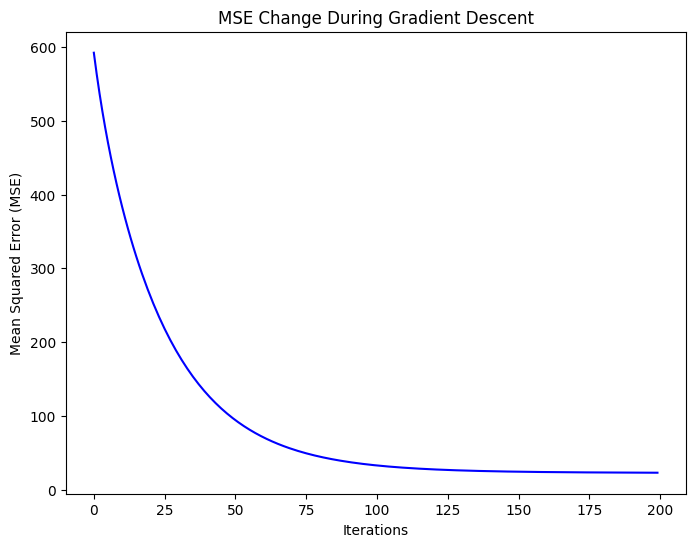

In [25]:
plt.figure(figsize=(8,6))
plt.plot(range(iterations), mse_history, color='blue')
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE Change During Gradient Descent")
plt.show()